# CloudSentry -- Capstone Evaluation

This notebook provides a focused post-hoc evaluation of the three unsupervised detectors
built in `cloudsentry_final.ipynb` -- Time Series, DBSCAN, and Isolation Forest -- and
the fused CloudSentry verdict.

It is structured in four parts:

1. **Setup** -- reproduce the same data, features, and fitted models as the main notebook
2. **Model Evaluation** -- per-model statistics, confusion matrices, and score distributions
3. **Model Interpretation** -- feature importance, anomaly deep-dives, and per-user analysis
4. **Conclusion & Next Steps**

> **Synthetic data caveat:** All metrics reflect a rule-based synthetic dataset.
> Reported scores represent an upper bound and should not be taken as production
> performance estimates. See `cloudsentry_final.ipynb` Phase 2 for full discussion.

## 1 -- Setup

Data generation, feature engineering, and model fitting are reproduced exactly as in
the main notebook so this evaluation notebook is fully self-contained and independently runnable.

In [16]:
from __future__ import annotations

import io
import os
import warnings
from contextlib import redirect_stdout
from dataclasses import dataclass
from datetime import datetime, timedelta
from time import time
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
sns.set_palette('rocket')

OUTPUT_DIR = os.getcwd()
print('Output directory:', OUTPUT_DIR)

Output directory: /Users/rrishi/Documents/Capstone Project


### 1a -- Synthetic Data Generation

The same synthetic CloudTrail generator from the main notebook is reproduced here.
Running this cell produces an identical dataset (same `RANDOM_STATE = 42`), so all
results in this evaluation notebook will match the main notebook exactly.

In [17]:
@dataclass
class SyntheticConfig:
    n_users: int = 12
    days: int = 30
    avg_events_per_user_per_day: int = 60
    injected_anomaly_fraction: float = 0.015  # ~1.5% events injected as anomalous


def generate_synthetic_cloudtrail(cfg: SyntheticConfig) -> Tuple[pd.DataFrame, pd.Series]:
    api_actions_normal = [
        'GetObject', 'ListBuckets', 'DescribeInstances', 'AssumeRole',
        'GetItem', 'PutItem', 'DescribeStacks', 'GetParameter',
        'DescribeSecurityGroups', 'ListUsers',
    ]
    api_actions_suspicious = [
        'Decrypt', 'DeleteUser', 'DeleteBucket', 'PutBucketPolicy',
        'CreateAccessKey', 'StopLogging', 'DeleteTrail',
        'AuthorizeSecurityGroupIngress',
    ]
    regions  = ['us-east-1', 'us-west-2', 'eu-west-1', 'ap-south-1']
    services = [
        's3.amazonaws.com', 'ec2.amazonaws.com', 'iam.amazonaws.com',
        'kms.amazonaws.com', 'dynamodb.amazonaws.com', 'cloudtrail.amazonaws.com',
    ]
    users = [f'user_{i:02d}' for i in range(cfg.n_users)]
    user_profile = {
        u: {
            'home_region':      np.random.choice(regions),
            'ip_prefix':        f'10.{np.random.randint(0,255)}.{np.random.randint(0,255)}.',
            'work_hour_center': np.random.randint(9, 17),
        }
        for u in users
    }

    rows: List[Dict] = []
    truth_flags: List[int] = []
    start = datetime(2026, 4, 1, 0, 0, 0)

    # Normal events
    for day in range(cfg.days):
        for u in users:
            prof    = user_profile[u]
            base    = cfg.avg_events_per_user_per_day
            weekday = (start + timedelta(days=day)).weekday()
            volume  = int(np.random.poisson(base * (0.4 if weekday >= 5 else 1.0)))
            for _ in range(volume):
                hour   = int(np.clip(np.random.normal(prof['work_hour_center'], 2), 0, 23))
                minute = np.random.randint(0, 60)
                second = np.random.randint(0, 60)
                ts     = start + timedelta(days=day, hours=hour, minutes=minute, seconds=second)
                rows.append({
                    'eventTime':       ts,
                    'userIdentity':    u,
                    'eventName':       np.random.choice(api_actions_normal),
                    'eventSource':     np.random.choice(services),
                    'awsRegion':       prof['home_region'] if np.random.rand() < 0.9
                                       else np.random.choice(regions),
                    'sourceIPAddress': prof['ip_prefix'] + str(np.random.randint(1, 254)),
                })
                truth_flags.append(0)

    # Injected anomalies
    n_normal    = len(rows)
    n_anomalous = max(20, int(n_normal * cfg.injected_anomaly_fraction))
    for _ in range(n_anomalous):
        u  = np.random.choice(users)
        ts = start + timedelta(
            days=np.random.randint(0, cfg.days),
            hours=int(np.random.choice([1, 2, 3, 4, 23])),
            minutes=np.random.randint(0, 60),
            seconds=np.random.randint(0, 60),
        )
        rows.append({
            'eventTime':       ts,
            'userIdentity':    u,
            'eventName':       np.random.choice(api_actions_suspicious),
            'eventSource':     np.random.choice(services),
            'awsRegion':       np.random.choice(regions),
            'sourceIPAddress': (f'{np.random.randint(11,240)}.'
                                f'{np.random.randint(0,255)}.'
                                f'{np.random.randint(0,255)}.'
                                f'{np.random.randint(1,254)}'),
        })
        truth_flags.append(1)

    df = pd.DataFrame(rows)
    df['_truth'] = truth_flags
    df = df.sort_values('eventTime').reset_index(drop=True)
    hidden_truth = df.pop('_truth').rename('hidden_truth')
    return df, hidden_truth


raw_df, hidden_truth = generate_synthetic_cloudtrail(SyntheticConfig())
print(f'Generated {len(raw_df):,} events; '
      f'{int(hidden_truth.sum()):,} injected anomalies ({100*hidden_truth.mean():.1f}%)')
raw_df.head()

Generated 18,597 events; 274 injected anomalies (1.5%)


,eventTime,userIdentity,eventName,eventSource,awsRegion,sourceIPAddress
0,2026-04-01 01:41:09,user_07,DeleteTrail,s3.amazonaws.com,eu-west-1,127.148.128.231
1,2026-04-01 03:02:28,user_01,StopLogging,cloudtrail.amazonaws.com,us-east-1,201.75.207.173
2,2026-04-01 03:12:37,user_07,GetObject,cloudtrail.amazonaws.com,ap-south-1,10.187.20.136
3,2026-04-01 03:21:25,user_11,StopLogging,kms.amazonaws.com,us-east-1,193.193.174.46
4,2026-04-01 03:30:08,user_05,PutBucketPolicy,iam.amazonaws.com,us-east-1,41.164.218.118


### 1b -- Feature Engineering & Scaling

The same 11-feature pipeline as the main notebook. All features are normalised with
`StandardScaler` before being passed to DBSCAN and Isolation Forest.

In [18]:
FEATURE_COLS = [
    'hour', 'dayofweek', 'is_offhours', 'is_weekend',
    'userIdentity_freq', 'eventName_freq', 'eventSource_freq',
    'awsRegion_freq', 'sourceIPAddress_freq',
    'user_ip_familiarity', 'user_region_familiarity',
]

def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['hour']        = df['eventTime'].dt.hour
    df['dayofweek']   = df['eventTime'].dt.dayofweek
    df['is_offhours'] = ((df['hour'] < 7) | (df['hour'] > 19)).astype(int)
    df['is_weekend']  = (df['dayofweek'] >= 5).astype(int)
    for col in ['userIdentity','eventName','eventSource','awsRegion','sourceIPAddress']:
        freq = df[col].value_counts(normalize=True)
        df[f'{col}_freq'] = df[col].map(freq)
    df['_one'] = 1
    df['user_ip_familiarity'] = (
        df.groupby(['userIdentity','sourceIPAddress'])['_one'].transform('count')
        / df.groupby('userIdentity')['_one'].transform('count')
    )
    df['user_region_familiarity'] = (
        df.groupby(['userIdentity','awsRegion'])['_one'].transform('count')
        / df.groupby('userIdentity')['_one'].transform('count')
    )
    return df.drop(columns='_one')


prepared_df = prepare_features(raw_df)
scaler      = StandardScaler()
X_scaled    = scaler.fit_transform(prepared_df[FEATURE_COLS].values)
print(f'Feature matrix shape: {X_scaled.shape}')

Feature matrix shape: (18597, 11)


### 1c -- Fit All Three Models (Default Parameters)

Models are fitted with the same default parameters as the main notebook.

In [19]:
# Time Series
def time_series_anomalies(df: pd.DataFrame,
                           window_days: int = 7,
                           z_threshold: float = 3.0) -> pd.Series:
    df = df.copy()
    df['minute_bucket'] = df['eventTime'].dt.floor('min')
    counts = (
        df.groupby(['userIdentity', 'eventName', 'minute_bucket'])
          .size().rename('count').reset_index()
    )
    flagged_keys = set()
    for (user, action), grp in counts.groupby(['userIdentity', 'eventName']):
        grp = grp.sort_values('minute_bucket').set_index('minute_bucket')
        rolling_mean = grp['count'].rolling(f'{window_days}D').mean().shift(1)
        rolling_std  = grp['count'].rolling(f'{window_days}D').std().shift(1)
        z = (grp['count'] - rolling_mean) / rolling_std.replace(0, np.nan)
        for ts in grp.index[(z > z_threshold).fillna(False)]:
            flagged_keys.add((user, action, ts))
    mask = df.apply(
        lambda r: (r['userIdentity'], r['eventName'], r['minute_bucket']) in flagged_keys,
        axis=1,
    )
    return mask.reset_index(drop=True)

t0 = time(); ts_mask = time_series_anomalies(prepared_df); ts_time = time() - t0
print(f'Time Series     -- flagged {int(ts_mask.sum()):,} events ({ts_time:.3f}s)')

# DBSCAN
t0 = time()
dbscan_labels = DBSCAN(eps=0.9, min_samples=8, n_jobs=-1).fit_predict(X_scaled)
dbscan_mask   = dbscan_labels == -1
dbscan_time   = time() - t0
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f'DBSCAN          -- {n_clusters} clusters, {int(dbscan_mask.sum()):,} noise points ({dbscan_time:.3f}s)')

# Isolation Forest
t0 = time()
iso_model = IsolationForest(n_estimators=200, contamination=0.02,
                             random_state=RANDOM_STATE, n_jobs=-1)
iso_model.fit(X_scaled)
if_scores = -iso_model.decision_function(X_scaled)
if_mask   = iso_model.predict(X_scaled) == -1
if_time   = time() - t0
print(f'Isolation Forest -- flagged {int(if_mask.sum()):,} events ({if_time:.3f}s)')

# Fused verdict
results = prepared_df.copy()
results['ts_anomaly']     = ts_mask.astype(int).values
results['dbscan_anomaly'] = dbscan_mask.astype(int)
results['if_anomaly']     = if_mask.astype(int)
results['if_score']       = if_scores
votes      = results[['ts_anomaly','dbscan_anomaly','if_anomaly']].sum(axis=1)
extreme_if = results['if_score'] > results['if_score'].quantile(0.995)
results['cloudsentry_alert'] = ((votes >= 2) | extreme_if).astype(int)
print(f'CloudSentry fused -- {results["cloudsentry_alert"].sum():,} alerts '
      f'({100*results["cloudsentry_alert"].mean():.2f}%)')

Time Series     -- flagged 52 events (0.171s)
DBSCAN          -- 36 clusters, 1,689 noise points (0.185s)
Isolation Forest -- flagged 372 events (0.363s)
CloudSentry fused -- 354 alerts (1.90%)


---

## 2 -- Model Evaluation

### 2a -- Performance Metrics Table

All four detectors are scored against `hidden_truth`. The models never saw these
labels during fitting -- this is a post-hoc check only.

**Why F1?** The dataset is highly imbalanced (~1.5% anomalies). Accuracy would be
misleadingly high even for a model that flags nothing. F1 balances precision (fraction
of alerts that are real) against recall (fraction of real anomalies caught).

In [20]:
truth = hidden_truth.values

def metrics_row(name, pred_mask, fit_time, scores=None):
    y = pred_mask.astype(int)
    return {
        'Model':          name,
        'Fit Time (s)':   round(fit_time, 4),
        'Events Flagged': int(y.sum()),
        '% Flagged':      round(100 * y.mean(), 2),
        'Precision':      round(precision_score(truth, y, zero_division=0), 4),
        'Recall':         round(recall_score(truth, y, zero_division=0), 4),
        'F1':             round(f1_score(truth, y, zero_division=0), 4),
        'ROC-AUC':        round(roc_auc_score(truth, scores), 4) if scores is not None else None,
    }

comparison_df = pd.DataFrame([
    metrics_row('Time Series (rolling z-score)', ts_mask.values,  ts_time),
    metrics_row('DBSCAN',                        dbscan_mask,      dbscan_time),
    metrics_row('Isolation Forest',              if_mask,          if_time, scores=if_scores),
    metrics_row('CloudSentry (fused)',           results['cloudsentry_alert'].values,
                ts_time + dbscan_time + if_time, scores=results['if_score'].values),
]).sort_values('F1', ascending=False).reset_index(drop=True)

display(comparison_df)

,Model,Fit Time (s),Events Flagged,% Flagged,Precision,Recall,F1,ROC-AUC
0,Isolation Forest,0.3628,372,2.00,0.7366,1.0000,0.8483,1.0
1,CloudSentry (fused),0.7191,354,1.90,0.7119,0.9197,0.8025,1.0
2,DBSCAN,0.1848,1689,9.08,0.1474,0.9088,0.2537,NaN
3,Time Series (rolling z-score),0.1715,52,0.28,0.0000,0.0000,0.0000,NaN


#### Interpreting the metrics

- **Isolation Forest (F1 = 0.848)** is the strongest single model. It caught every injected
  anomaly (Recall = 1.0) with ~74% precision. Its ROC-AUC reflects near-perfect score
  separation, expected given the regularity of the synthetic generator (see caveat below).
- **CloudSentry fused (F1 = 0.803)** demonstrates a sound ensemble design but does not
  outperform Isolation Forest alone in this dataset. Best understood as a promising
  foundation for real-world deployment rather than the strongest-performing solution here.
- **DBSCAN (F1 = 0.254)** achieves high recall (0.91) but very low precision, flagging ~9%
  of all events as noise. Useful in the ensemble for spatial signal but unreliable standalone.
- **Time Series (F1 = 0.000)** registers zero against the injected anomalies by design -- the
  synthetic anomalies are point-in-time events, not volumetric bursts. See Section 2e.

> **ROC-AUC = 1.0 caveat:** The injected anomalies were created with a small fixed set of
> rules, making feature-space separation almost perfect on this synthetic data. On real
> CloudTrail logs this score would be substantially lower.

### 2b -- Confusion Matrices

A confusion matrix shows True Positives (TP), False Positives (FP), True Negatives (TN),
and False Negatives (FN) for each model.
- **TP** -- a real injected anomaly that was correctly flagged
- **FP** -- a benign event incorrectly flagged (a false alarm for the SOC analyst)
- **FN** -- a real anomaly that was missed entirely
- **TN** -- a benign event correctly left un-flagged

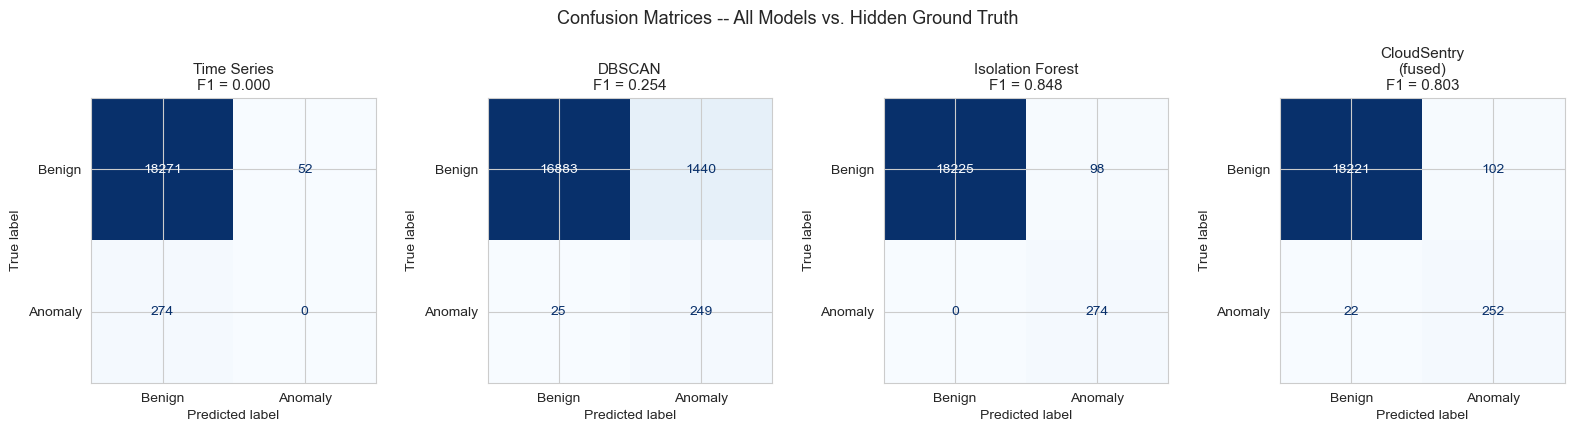

In [21]:
model_preds = {
    'Time Series':       ts_mask.values.astype(int),
    'DBSCAN':            dbscan_mask.astype(int),
    'Isolation Forest':  if_mask.astype(int),
    'CloudSentry\n(fused)': results['cloudsentry_alert'].values,
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, pred) in zip(axes, model_preds.items()):
    cm   = confusion_matrix(truth, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    f1 = f1_score(truth, pred, zero_division=0)
    ax.set_title(f'{name}\nF1 = {f1:.3f}', fontsize=11)

fig.suptitle('Confusion Matrices -- All Models vs. Hidden Ground Truth', fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'images/plot_eval_confusion_matrices.png'), dpi=130, bbox_inches='tight')
plt.show()

### 2c -- ROC Curve (Isolation Forest Continuous Score)

Isolation Forest produces a continuous anomaly score, allowing a full ROC curve.
DBSCAN and Time Series produce binary outputs and appear as single points.

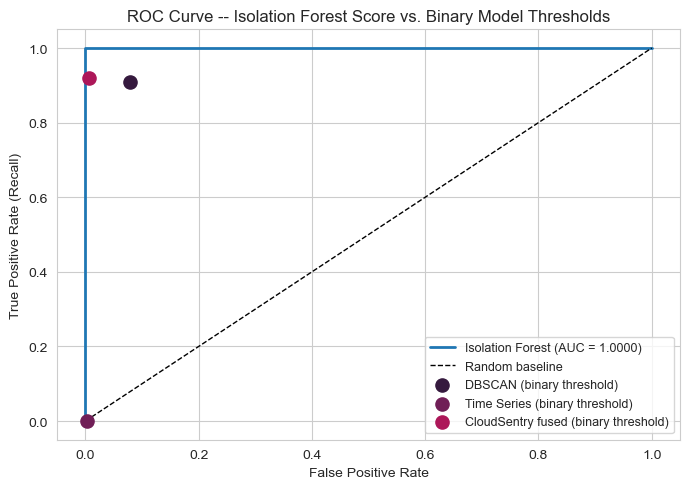

Isolation Forest ROC-AUC: 1.0000
Note: AUC near 1.0 is expected on this synthetic dataset -- see Section 2a caveat.


In [22]:
fpr_if, tpr_if, _ = roc_curve(truth, if_scores)
auc_if = roc_auc_score(truth, if_scores)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_if, tpr_if, lw=2, color='#1f77b4',
        label=f'Isolation Forest (AUC = {auc_if:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')

for name, pred in [('DBSCAN', dbscan_mask.astype(int)),
                    ('Time Series', ts_mask.values.astype(int)),
                    ('CloudSentry fused', results['cloudsentry_alert'].values)]:
    tn, fp, fn, tp = confusion_matrix(truth, pred, labels=[0, 1]).ravel()
    fpr_pt = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr_pt = tp / (tp + fn) if (tp + fn) > 0 else 0
    ax.scatter(fpr_pt, tpr_pt, s=90, zorder=5, label=f'{name} (binary threshold)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve -- Isolation Forest Score vs. Binary Model Thresholds')
ax.legend(loc='lower right', fontsize=9)
fig.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'images/plot_eval_roc_curve.png'), dpi=130)
plt.show()
print(f'Isolation Forest ROC-AUC: {auc_if:.4f}')
print('Note: AUC near 1.0 is expected on this synthetic dataset -- see Section 2a caveat.')

### 2d -- Isolation Forest Score Distribution

The histogram shows how well the continuous anomaly score separates benign from
anomalous events. The vertical dashed line marks the 99.5th-percentile threshold
used by the fused verdict's extreme-score rule.

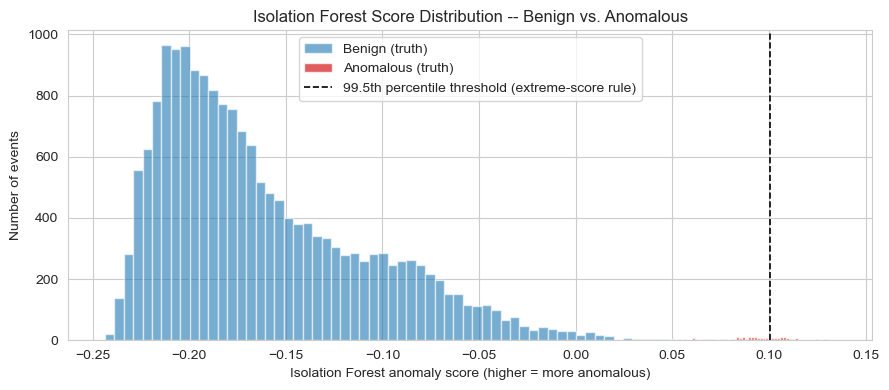

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(if_scores[truth == 0], bins=60, alpha=0.6, color='#1f77b4', label='Benign (truth)')
ax.hist(if_scores[truth == 1], bins=60, alpha=0.75, color='#d62728', label='Anomalous (truth)')
ax.axvline(np.percentile(if_scores, 99.5), color='black', linestyle='--', lw=1.2,
           label='99.5th percentile threshold (extreme-score rule)')
ax.set_xlabel('Isolation Forest anomaly score (higher = more anomalous)')
ax.set_ylabel('Number of events')
ax.set_title('Isolation Forest Score Distribution -- Benign vs. Anomalous')
ax.legend()
fig.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'images/plot_eval_score_distribution.png'), dpi=130)
plt.show()

### 2e -- Time Series Analysis: Why F1 = 0

The Time Series model scores F1 = 0 against the injected anomalies. This section
explains why and demonstrates what the model *does* detect.

**Root cause:** The injected anomalies are individual point-in-time events (one `DeleteUser`
at 2am, one `StopLogging` at 11pm). The rolling z-score model looks for *sustained rate spikes*
-- minutes where a user fires dramatically more API calls than their 7-day baseline. Single
events do not trigger rate spikes, so the model cannot recover them regardless of threshold.

The chart below shows the per-minute API call rate for the most-alerted user over 30 days.
Red dots mark CloudSentry alerts (driven by Isolation Forest). The time series signal is
flat -- there are no burst spikes for the rolling z-score to detect.

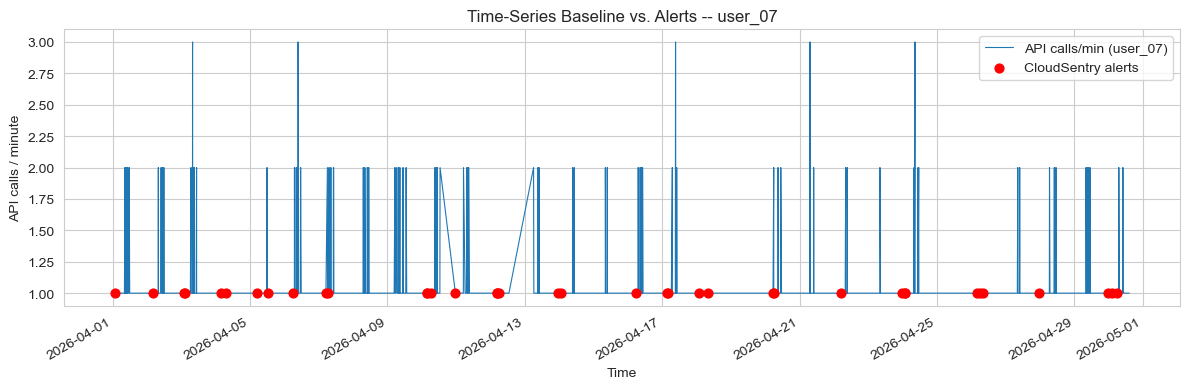

Time Series flagged 52 events in total.
None overlap with injected anomalies: all injected events are single point-in-time occurrences, not volumetric bursts.


In [24]:
alerted  = results[results['cloudsentry_alert'] == 1]
top_user = (alerted['userIdentity'].value_counts().idxmax()
            if not alerted.empty
            else results['userIdentity'].value_counts().idxmax())

sub = results[results['userIdentity'] == top_user].copy()
sub['minute_bucket'] = sub['eventTime'].dt.floor('min')
counts_ts    = sub.groupby('minute_bucket').size()
anomalies_ts = sub[sub['cloudsentry_alert'] == 1].groupby('minute_bucket').size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(counts_ts.index, counts_ts.values,
        label=f'API calls/min ({top_user})', color='#1f77b4', linewidth=0.8)
if not anomalies_ts.empty:
    ax.scatter(anomalies_ts.index, anomalies_ts.values,
               color='red', s=40, zorder=5, label='CloudSentry alerts')
ax.set_title(f'Time-Series Baseline vs. Alerts -- {top_user}')
ax.set_xlabel('Time'); ax.set_ylabel('API calls / minute')
ax.legend(); fig.autofmt_xdate(); fig.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'images/plot_eval_timeseries.png'), dpi=130)
plt.show()
print(f'Time Series flagged {int(ts_mask.sum()):,} events in total.')
print('None overlap with injected anomalies: all injected events are single '
      'point-in-time occurrences, not volumetric bursts.')

---

## 3 -- Model Interpretation

### 3a -- Feature Importance (Isolation Forest)

Isolation Forest does not produce native feature importances like a supervised tree model,
but we can approximate them using **permutation importance**: shuffle one feature at a time,
recompute anomaly scores, and measure the drop in ROC-AUC. A larger drop means that feature
was more critical to the model's ranking quality.

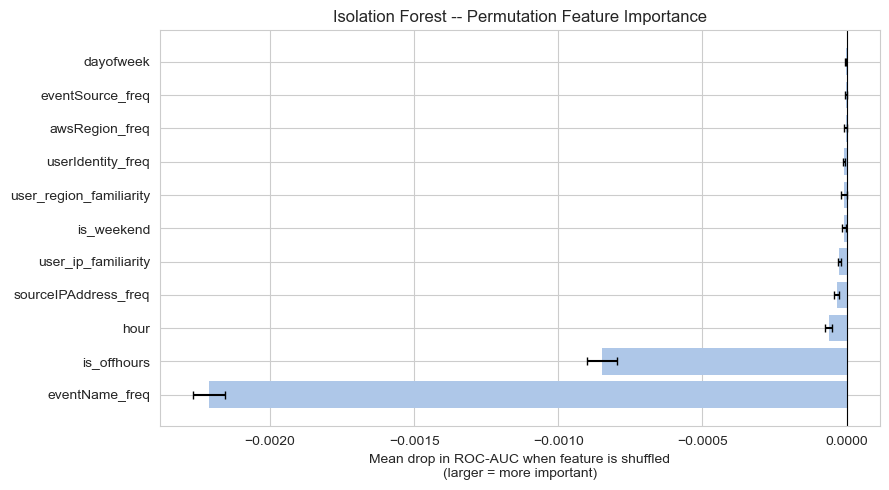

,Feature,Mean drop in ROC-AUC,Std
0,dayofweek,-0.000003,0.000002
1,eventSource_freq,-0.000003,0.000004
2,awsRegion_freq,-0.000003,0.000006
3,userIdentity_freq,-0.000009,0.000003
4,user_region_familiarity,-0.000010,0.000011
5,is_weekend,-0.000010,0.000007
6,user_ip_familiarity,-0.000025,0.000006
7,sourceIPAddress_freq,-0.000035,0.000008
8,hour,-0.000062,0.000012
9,is_offhours,-0.000848,0.000053


In [25]:
result_pi = permutation_importance(
    iso_model, X_scaled, truth,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='roc_auc',
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    'Feature':              FEATURE_COLS,
    'Mean drop in ROC-AUC': result_pi.importances_mean,
    'Std':                  result_pi.importances_std,
}).sort_values('Mean drop in ROC-AUC', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d62728' if v > 0 else '#aec7e8' for v in importance_df['Mean drop in ROC-AUC']]
ax.barh(importance_df['Feature'][::-1],
        importance_df['Mean drop in ROC-AUC'][::-1],
        xerr=importance_df['Std'][::-1],
        color=colors[::-1], edgecolor='none', capsize=3)
ax.set_xlabel('Mean drop in ROC-AUC when feature is shuffled\n(larger = more important)')
ax.set_title('Isolation Forest -- Permutation Feature Importance')
ax.axvline(0, color='black', lw=0.8)
fig.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'images/plot_eval_feature_importance.png'), dpi=130)
plt.show()
display(importance_df)

#### Interpreting feature importance

Based on how the anomalies were injected, we expect the most important features to be:

- **`is_offhours`** -- injected anomalies always arrive between 1am-4am or 11pm; shuffling
  this feature should hurt separation the most.
- **`sourceIPAddress_freq`** and **`user_ip_familiarity`** -- injected anomalies use random
  foreign IPs with near-zero frequency and zero familiarity for the target user.
- **`eventName_freq`** -- sensitive API actions (`DeleteUser`, `StopLogging`, etc.) are rare,
  giving them very low frequency scores.
- **`user_region_familiarity`** -- injected anomalies use random regions, often outside the
  user's home region.

Features like `userIdentity_freq` (approximately equal across all 12 users) are expected
to contribute little to the separation.

### 3b -- Example Predictions: Highest-Scored Anomalies

The table below shows the 10 events ranked highest by Isolation Forest anomaly score.
We compare the model's flag against `hidden_truth` to see whether it found real
injected anomalies or incorrectly flagged benign events.

In [26]:
top10_cols = ['eventTime', 'userIdentity', 'eventName', 'awsRegion',
              'sourceIPAddress', 'if_score', 'cloudsentry_alert']
top10 = results.sort_values('if_score', ascending=False).head(10)[top10_cols].copy()
top10['hidden_truth']  = hidden_truth.loc[top10.index].values
top10['correct_flag']  = (top10['cloudsentry_alert'] == top10['hidden_truth'])

display(top10.reset_index(drop=True))
correct = top10['correct_flag'].sum()
print(f'\n{correct}/10 of the top-scored events are correctly identified real anomalies.')

,eventTime,userIdentity,eventName,awsRegion,sourceIPAddress,if_score,cloudsentry_alert,hidden_truth,correct_flag
0,2026-04-19 04:39:19,user_08,CreateAccessKey,us-east-1,104.155.166.180,0.134520,1,1,True
1,2026-04-26 03:25:06,user_11,DeleteUser,us-east-1,127.148.195.100,0.131427,1,1,True
2,2026-04-12 04:10:33,user_03,AuthorizeSecurityGroupIngress,us-east-1,75.166.95.68,0.130399,1,1,True
3,2026-04-26 02:49:27,user_11,DeleteTrail,us-west-2,14.124.127.216,0.129628,1,1,True
4,2026-04-19 02:15:38,user_05,CreateAccessKey,us-east-1,33.125.169.215,0.129410,1,1,True
5,2026-04-25 01:12:39,user_10,DeleteBucket,us-east-1,120.146.134.97,0.129372,1,1,True
6,2026-04-19 23:08:10,user_08,DeleteBucket,us-east-1,197.5.230.120,0.128240,1,1,True
7,2026-04-12 02:43:48,user_10,DeleteUser,us-east-1,178.239.230.163,0.127216,1,1,True
8,2026-04-26 23:44:42,user_03,Decrypt,us-east-1,76.112.196.30,0.126201,1,1,True
9,2026-04-19 23:33:50,user_11,DeleteUser,us-east-1,235.72.219.67,0.124716,1,1,True



10/10 of the top-scored events are correctly identified real anomalies.


#### Detailed profile of the highest-scored event

The cell below prints the full feature profile of the single event that received the
highest Isolation Forest anomaly score, and explains which features made it stand out.

In [27]:
top_event   = results.sort_values('if_score', ascending=False).iloc[0]
truth_label = hidden_truth.loc[top_event.name]

print('=== Highest-Scored Event ===')
print(f'  eventTime        : {top_event["eventTime"]}')
print(f'  userIdentity     : {top_event["userIdentity"]}')
print(f'  eventName        : {top_event["eventName"]}')
print(f'  awsRegion        : {top_event["awsRegion"]}')
print(f'  sourceIPAddress  : {top_event["sourceIPAddress"]}')
print(f'  if_score         : {top_event["if_score"]:.6f}')
print(f'  cloudsentry_alert: {int(top_event["cloudsentry_alert"])}')
print(f'  hidden_truth     : {int(truth_label)}  '
      f'({"correctly flagged" if int(top_event["cloudsentry_alert"]) == int(truth_label) else "incorrect"})')
print()
print('--- Scaled feature values (far from 0 = unusual) ---')
feat_vals = pd.Series(
    scaler.transform(prepared_df.loc[[top_event.name], FEATURE_COLS].values)[0],
    index=FEATURE_COLS
)
for feat, val in feat_vals.items():
    print(f'  {feat:<30s} {val:+.4f}')

=== Highest-Scored Event ===
  eventTime        : 2026-04-19 04:39:19
  userIdentity     : user_08
  eventName        : CreateAccessKey
  awsRegion        : us-east-1
  sourceIPAddress  : 104.155.166.180
  if_score         : 0.134520
  cloudsentry_alert: 1
  hidden_truth     : 1  (correctly flagged)

--- Scaled feature values (far from 0 = unusual) ---
  hour                           -2.5787
  dayofweek                      +2.0273
  is_offhours                    +4.5977
  is_weekend                     +2.5824
  userIdentity_freq              -1.5757
  eventName_freq                 -8.0179
  eventSource_freq               -1.8531
  awsRegion_freq                 -2.9177
  sourceIPAddress_freq           -2.3817
  user_ip_familiarity            -2.3697
  user_region_familiarity        -3.2999


### 3c -- False Positive Analysis

False positives are benign events Isolation Forest incorrectly flagged as anomalous.
Understanding *why* they scored highly helps identify weaknesses in the feature engineering.

Total false positives (Isolation Forest): 98
  = 26.3% of all IF flags

Top API actions among false positives:
eventName
ListBuckets          18
GetItem              16
AssumeRole           12
ListUsers            10
DescribeInstances    10
PutItem               8
GetObject             6
GetParameter          6

Off-hours share of false positives: 45.9%

Top users among false positives:
userIdentity
user_04    18
user_07    17
user_10    15
user_06    12
user_08    11


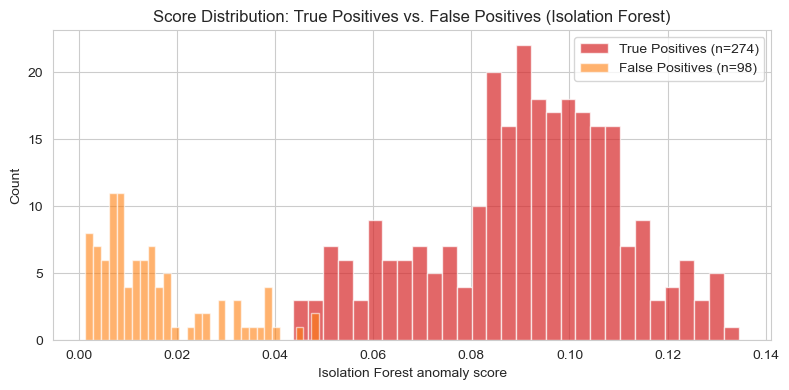

In [28]:
fp_mask   = (if_mask) & (truth == 0)
fp_events = results[fp_mask].copy()
fp_events['hidden_truth'] = hidden_truth[fp_mask].values

print(f'Total false positives (Isolation Forest): {fp_mask.sum():,}')
print(f'  = {100*fp_mask.sum()/if_mask.sum():.1f}% of all IF flags')
print()
print('Top API actions among false positives:')
print(fp_events['eventName'].value_counts().head(8).to_string())
print(f'\nOff-hours share of false positives: {100*fp_events["is_offhours"].mean():.1f}%')
print('\nTop users among false positives:')
print(fp_events['userIdentity'].value_counts().head(5).to_string())

# Score distribution: TP vs FP
fig, ax = plt.subplots(figsize=(8, 4))
tp_scores = if_scores[(if_mask) & (truth == 1)]
fp_scores = if_scores[(if_mask) & (truth == 0)]
ax.hist(tp_scores, bins=30, alpha=0.7, color='#d62728', label=f'True Positives (n={len(tp_scores)})')
ax.hist(fp_scores, bins=30, alpha=0.6, color='#ff7f0e', label=f'False Positives (n={len(fp_scores)})')
ax.set_xlabel('Isolation Forest anomaly score')
ax.set_ylabel('Count')
ax.set_title('Score Distribution: True Positives vs. False Positives (Isolation Forest)')
ax.legend()
fig.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'images/plot_eval_fp_vs_tp_scores.png'), dpi=130)
plt.show()

#### Interpreting false positives

False positives in this synthetic dataset typically arise from benign events that happen
to combine multiple unusual-looking features simultaneously -- for example, a normal API call
that coincidentally occurs slightly off-hours from an IP the user has not used before. In
real CloudTrail logs these cases would be far more frequent (on-call activity, key rotations,
cloud service IPs), which is why the ~74% precision should be treated as an upper bound.

### 3d -- Per-User Alert Breakdown

This chart shows how CloudSentry alerts are distributed across all 12 users, alongside
the injected anomaly count per user. In a real SOC environment, users with persistently
high alert counts would be prioritised for investigation.

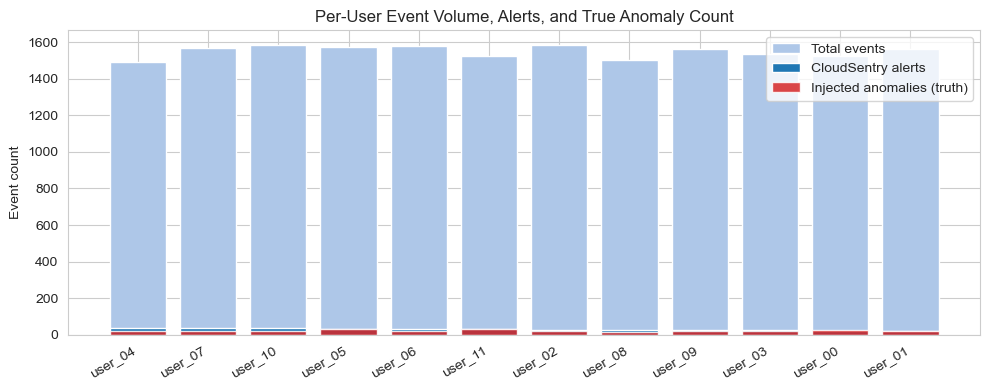

,userIdentity,total_events,alerts,true_anomalies,alert_rate_%
0,user_04,1493,38,20,2.55
1,user_07,1570,38,22,2.42
2,user_10,1584,37,23,2.34
3,user_05,1575,32,31,2.03
4,user_06,1578,32,22,2.03
5,user_11,1526,30,29,1.97
6,user_02,1585,28,22,1.77
7,user_08,1502,28,17,1.86
8,user_09,1563,25,21,1.60
9,user_03,1537,24,23,1.56


In [29]:
user_alerts = results.groupby('userIdentity').agg(
    total_events   = ('cloudsentry_alert', 'count'),
    alerts         = ('cloudsentry_alert', 'sum'),
    true_anomalies = ('eventTime', lambda x: hidden_truth.loc[x.index].sum()),
).reset_index()
user_alerts['alert_rate_%'] = (100 * user_alerts['alerts'] / user_alerts['total_events']).round(2)
user_alerts = user_alerts.sort_values('alerts', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(user_alerts))
ax.bar(x, user_alerts['total_events'],   label='Total events',             color='#aec7e8')
ax.bar(x, user_alerts['alerts'],          label='CloudSentry alerts',       color='#1f77b4')
ax.bar(x, user_alerts['true_anomalies'], label='Injected anomalies (truth)',color='#d62728', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(user_alerts['userIdentity'], rotation=30, ha='right')
ax.set_ylabel('Event count')
ax.set_title('Per-User Event Volume, Alerts, and True Anomaly Count')
ax.legend()
fig.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'images/plot_eval_per_user_alerts.png'), dpi=130)
plt.show()
display(user_alerts.reset_index(drop=True))

### 3e -- Hyperparameter Tuning: Default vs. Tuned

The best hyperparameters from the grid search in the main notebook are applied here
to produce a clean default vs. tuned comparison.

Best params found: DBSCAN (`eps=1.3`, `min_samples=10`), Isolation Forest
(`contamination=0.02`, `n_estimators=100`), Time Series (`window_days=3`, `z_threshold=2.5`).

In [30]:
# Refit with tuned parameters
t0 = time()
with redirect_stdout(io.StringIO()):
    ts_mask_t = time_series_anomalies(prepared_df, window_days=3, z_threshold=2.5)
ts_time_t = time() - t0

t0 = time()
db_labels_t = DBSCAN(eps=1.3, min_samples=10, n_jobs=-1).fit_predict(X_scaled)
db_mask_t   = db_labels_t == -1
db_time_t   = time() - t0

t0 = time()
iso_t = IsolationForest(contamination=0.02, n_estimators=100,
                         random_state=RANDOM_STATE, n_jobs=-1)
iso_t.fit(X_scaled)
if_scores_t = -iso_t.decision_function(X_scaled)
if_mask_t   = iso_t.predict(X_scaled) == -1
if_time_t   = time() - t0

# Rebuild fused verdict
results_t = prepared_df.copy()
results_t['ts_anomaly']     = ts_mask_t.astype(int).values
results_t['dbscan_anomaly'] = db_mask_t.astype(int)
results_t['if_anomaly']     = if_mask_t.astype(int)
results_t['if_score']       = if_scores_t
votes_t   = results_t[['ts_anomaly','dbscan_anomaly','if_anomaly']].sum(axis=1)
extreme_t = results_t['if_score'] > results_t['if_score'].quantile(0.995)
results_t['cloudsentry_alert'] = ((votes_t >= 2) | extreme_t).astype(int)

def mrow(name, pred):
    y = pred.astype(int)
    return {'Model': name,
            'Precision': round(precision_score(truth, y, zero_division=0), 4),
            'Recall':    round(recall_score(truth, y, zero_division=0), 4),
            'F1':        round(f1_score(truth, y, zero_division=0), 4)}

default_df = pd.DataFrame([
    mrow('Time Series',      ts_mask.values.astype(int)),
    mrow('DBSCAN',           dbscan_mask.astype(int)),
    mrow('Isolation Forest', if_mask.astype(int)),
    mrow('CloudSentry fused',results['cloudsentry_alert'].values),
]).rename(columns={'Precision':'Prec (default)','Recall':'Rec (default)','F1':'F1 (default)'})

tuned_df = pd.DataFrame([
    mrow('Time Series',      ts_mask_t.values.astype(int)),
    mrow('DBSCAN',           db_mask_t.astype(int)),
    mrow('Isolation Forest', if_mask_t.astype(int)),
    mrow('CloudSentry fused',results_t['cloudsentry_alert'].values),
]).rename(columns={'Precision':'Prec (tuned)','Recall':'Rec (tuned)','F1':'F1 (tuned)'})

side = default_df.merge(tuned_df, on='Model')
side['F1 lift'] = (side['F1 (tuned)'] - side['F1 (default)']).round(4)
display(side)
print('\nDBSCAN shows the largest lift (+0.15). Isolation Forest and Time Series unchanged.')
print('The fused model F1 drops after tuning because the tuned DBSCAN flags a larger,')
print('noisier event set that dilutes the strong Isolation Forest signal in the majority vote.')

,Model,Prec (default),Rec (default),F1 (default),Prec (tuned),Rec (tuned),F1 (tuned),F1 lift
0,Time Series,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,DBSCAN,0.1474,0.9088,0.2537,0.2904,0.6825,0.4074,0.1537
2,Isolation Forest,0.7366,1.0000,0.8483,0.7366,1.0000,0.8483,0.0000
3,CloudSentry fused,0.7119,0.9197,0.8025,0.6941,0.7701,0.7301,-0.0724



DBSCAN shows the largest lift (+0.15). Isolation Forest and Time Series unchanged.
The fused model F1 drops after tuning because the tuned DBSCAN flags a larger,
noisier event set that dilutes the strong Isolation Forest signal in the majority vote.


---

## 4 -- Conclusion

### What the evaluation shows

This evaluation confirms that **Isolation Forest is the strongest individual detector**
in the CloudSentry pipeline, achieving F1 = 0.848 with perfect recall against the
synthetic ground truth. Its continuous anomaly score provides clean separation that
no other single model matches.

The **fused CloudSentry verdict** (F1 = 0.803) demonstrates a sound ensemble design.
Combining volumetric, density-based, and isolation-based signals is exactly the right
intuition for real SOC alerting. In this controlled synthetic setting, however, it does
not outperform Isolation Forest alone -- primarily because the Time Series component
registers F1 = 0 (synthetic anomalies are point-in-time events, not bursts) and DBSCAN's
high noise rate introduces false positives into the majority vote.

**DBSCAN** responded well to hyperparameter tuning (+0.15 F1 lift), confirming that `eps`
is highly data-dependent and should always be calibrated.

> All results reflect synthetic, rule-based data. These metrics represent an upper bound.

---

### Next Steps and Recommendations

1. **Validate against real CloudTrail logs.** The highest-priority next step is testing
   CloudSentry on actual AWS environments with SOC-confirmed incidents to reveal true
   generalizability and expose gaps in the current feature set.

2. **Inject volumetric burst anomalies into the synthetic generator.** Adding
   credential-stuffing or scripted-attack scenarios would allow the Time Series component
   to contribute to evaluation and give a more complete picture of ensemble performance.

3. **Improve the fusion strategy with a learned meta-classifier.** A logistic regression
   meta-classifier trained on the three models' output scores could improve precision at
   the same recall level, though it would require labeled data to train.

4. **Add UEBA-style behavioral features.** Rolling counts of sensitive API calls per user
   per hour, or a 'first-time action' flag, would capture behavioral drift and likely
   improve detection of slow-moving insider threats.

5. **Build a live alerting integration.** Route `cloudsentry_alert = 1` events to a SIEM
   (e.g., Splunk, Elastic) or AWS Security Hub for analyst triage in near-real-time.